## RAG (Retrieval Augmented Generation)

It is the process of optimizing the output of a Large Language Model, so it references an authorative knowledge base outside of its training data sources before generating a response. Large Language Models are trained on vast volume of data and use billions of parameters to generate output for tasks like answering questions, translating languages, completing sentences, etc. RAG extends the already powerful capabilities of LLMs to specific domains or an organization's internal knowledge base, all without the need to retrain the model. It is a cost-effective approach to improve LLM output, so it remains relevant, accurate and useful in various contexts.

If we talk about a simple GenerativeAI application, it is like we provide a query to the llm with some instruction prompt and it generates the output based on training on billions of data availaible on the internet

So what are the disadvantages of this ??

Let's say this LLM is trained on vast past data, so it doesnt have knowledge of what currently happening or what currently happened recently, so if we try to ask it a question about anything recent, then it starts:
1. Hallucinating
- Basically when LLM dont have the information, then it will try to generate some answer, because it does not want to look like a fool, and it will make sure that it show the output in a form we have to beleive it, so its a major disadvantage of using only LLM.

2. Costly Fine Tunning of LLM
- Suppose there is a startup which have some data like policies, HR, Finance, etc and we have to make our model aware of that data, now here Fine Tunning can be done but Fine Tunning is a very costly task as we are tweaking those billion parameters of the model which is very time taking and costly. And maybe this data will be updated in future as well. So here RAG is a better option.

## How RAG Works

Basically with our previous setup where we had only a LLM which is generating a output based on user query and a instruction or system prompt. We will add a additional database called Vector Database, where we follow a Data Ingestion Pipeline. Now what is Data Ingestion Pipeline.

Data --> Parsing --> Chunking --> Embeddings --> Vectore DB

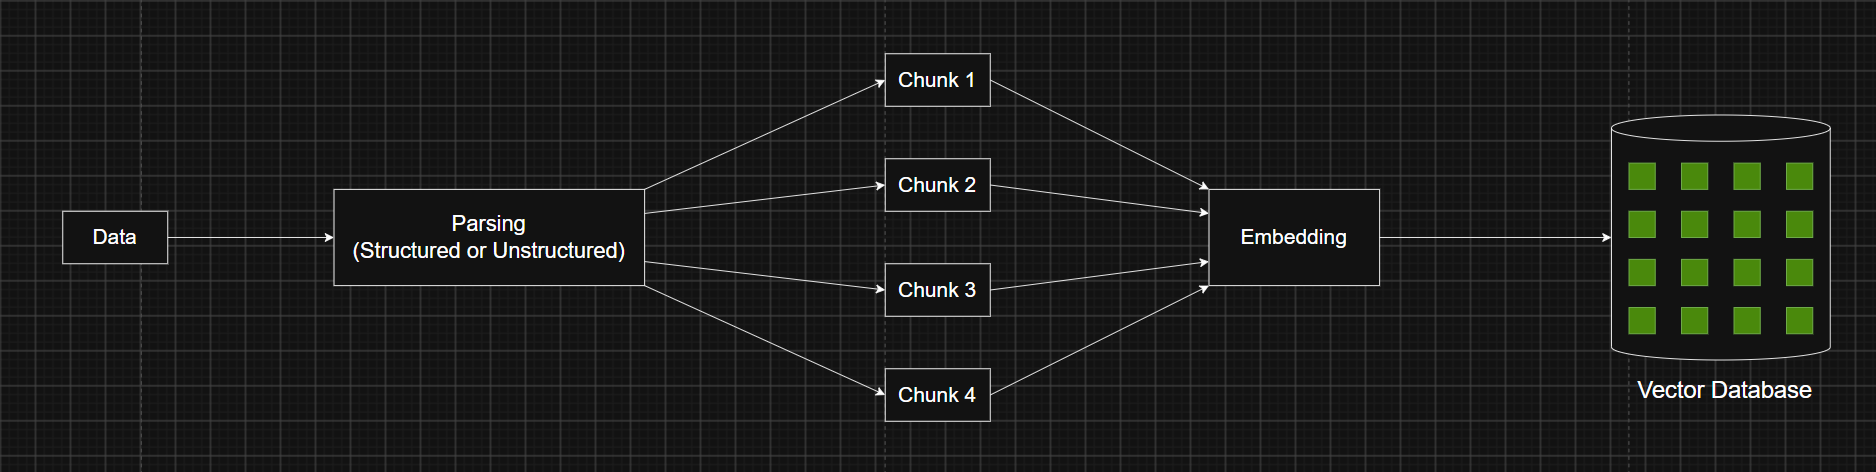

- This "Data" can be in any format like pdf, html, excel, SQL Database, etc.

- Parsing is taking this unstructured or structured data and convert it into a format so that our program can understand it and perform further steps like chunking. Parsing is important because suppose a pdf may contain images and tables, etc so chunking can not be done until the content is extracted.

- A chunk is basically a small, manageable portion of data. And chunking means dividing this parsed data into different chunks, because embeddings models have fixed context size and if we pass whole content at one time it will day that this is not possible, just like LLMs have fixed context size.

- Now after we get chunks we pass them to the embeddings model. Now the embeddings model will convert text to vectors. Embeddings will be applied to every chunk

- Then Vector DB will store these vectors for future calling or uses.

Note : Vectors are basically numerical representation of text in a form of list or we can say multi dimensional list, so we can apply algorithms like Similarity Search, Cosine Similarity, Euclidian Distance, etc due to which similar type of results can be retrieved from this Vector DB

Now our Setup looks like this (Retrieval Pipeline)

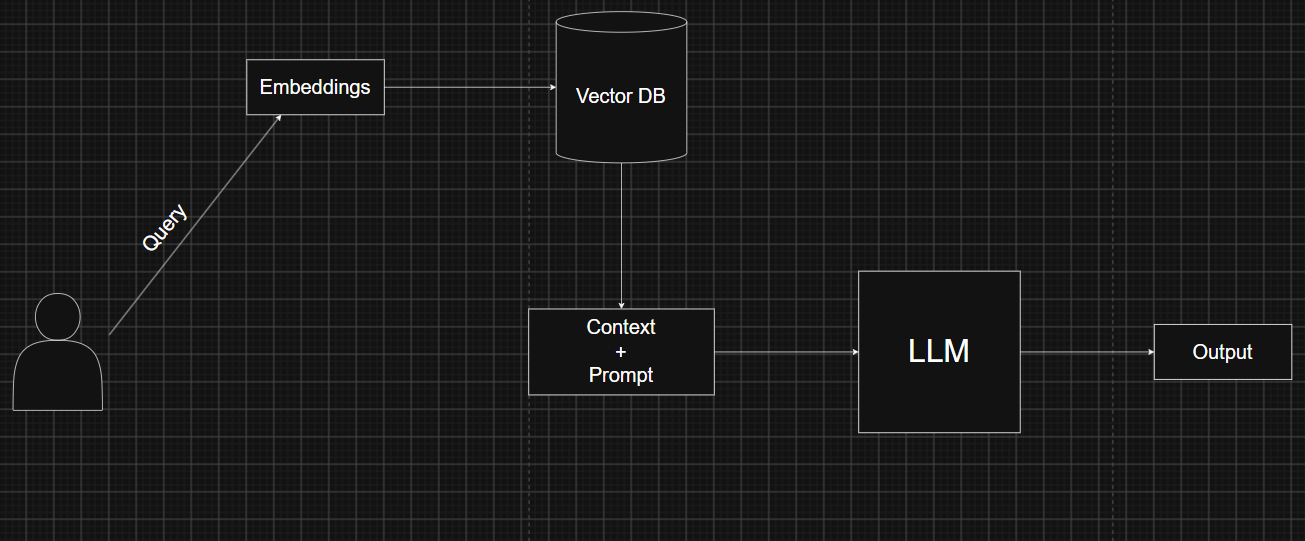

Now here when the user send query then it is also gets converted into embeddings so we can retrieve similar information from Vector DB by mathcing the embeddings of query with the embeddings stored in Vector DB with help of algorithms we talked above. Then the Vector DB will provide some amount of context which is attached with a prompt like "You can answer this query according to above context", and then it is passed to the LLM and we get the Output.

This is Traditional RAG and this setup is called Retrieval Pipeline

One of the greatest example of RAG Pipeline is Perplexity, it a complete RAG Application

Augmentation means giving a prompt with the context to the model

## Structured vs Unstructured Parsing

<b><u>1. Unstructured Parsing</b></u>

It depends on the parser like PyPDFParser from langchain is basic parser it creates Document (Document is basically a class object in Langchain to represent content with some metadata) object which contains content and metadata like :

--------------------------
<pre>
Machine Learning Guide

Introduction

Machine Learning is a field of AI.
It allows computers to learn from data.

Applications

Healthcare uses ML for diagnosis.
Finance uses ML for fraud detection.
</pre>
----------------------------
Here above it is not known that "Machine Learning Guide" is a heading or what

But on the other hand parsers like LlamaParse, UnstructuredFileLoader or Docling will provide output like

----------------------------
<pre>
elements = [
    {"type": "Title", "text": "Machine Learning Guide"},

    {"type": "Heading", "text": "Introduction"},

    {"type": "Paragraph",
     "text": "Machine Learning is a field of AI."},

    {"type": "Paragraph",
     "text": "It allows computers to learn from data."},

    {"type": "Heading",
     "text": "Applications"},

    {"type": "Paragraph",
     "text": "Healthcare uses ML for diagnosis."},

    {"type": "Paragraph",
     "text": "Finance uses ML for fraud detection."}
]
</pre>
------------------------------

Now if it returns Documents directly then we can directly do chunking from it and if it returns some other Data Structure like JSON, etc then we first convert it to Document and then do chunking and then finally pass them to embedding model to create embeddings and store in Vector DB.

Structured context help reducing hallucinations and increases accurace


Note : Chunks are small, manageable portion of data <u>in form of LangChain Document objects</u>. They are also a LangChain Document.

## How it is stored in a Vector DB

Every vector DB stores data differently, here is a overview of how it might be stored

-------------
<pre>
Vector
│
├── Embedding
│      [0.23, -0.41, ...]
│
├── Text
│      Healthcare uses ML for diagnosis.
│
└── Metadata
       page = 5
       heading = Applications
       source = ml.pdf

</pre>

-----------
Now here if we ask Use cases of ML then it will match it with the closest embedding and return a Document object with content and metadata like

-----------
<pre>
[
    Document(
        page_content="Healthcare uses ML for diagnosis.",
        metadata={
            "page": 5,
            "heading": "Applications"
        }
    )
]
</pre>
-----------

Now we generally pass the only content in traditional RAG but we can also pass this metadata which will enhance model understanding.

We will see both implementations